# **Partie 1 :Problème du Bandit Manchot à Bras Multiples  (Multi-Armed Bandit)**

## Objectif :
Dans ce travail pratique, vous allez explorer le problème du bandit manchot à bras multiples (Multi-Armed Bandit) et implémenter deux algorithmes classiques :


*   Epsilon-Greedy
*   Upper Confidence Bound (UCB)




Vous apprendrez à équilibrer exploration et exploitation pour maximiser les gains dans un environnement simulé. Vous analyserez également les performances de ces algorithmes.


## Contexte

Un bandit manchot à bras multiples est une machine fictive avec plusieurs bras. Chaque bras a une probabilité inconnue de fournir une récompense. L'objectif est de maximiser les gains en choisissant les bras de manière optimale.

Les défis principaux sont :



1.   **Exploration** : Tester de nouveaux bras pour découvrir leurs récompenses potentielles.
2.   **Exploitation** : Tirer le bras qui semble le plus rentable selon les connaissances actuelles.





# Import libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt

#1. Simuler l'envireneemnt

Chaque bras est associé à une récompense moyenne réelle (appelée "true reward"). Ces récompenses sont générées à l'aide d'une loi de probabilité. Par exemple, un bras peut suivre une distribution normale avec une moyenne de 0,5 et un écart-type de 0,1.
Illustration

Imaginez trois bras avec les récompenses suivantes :

    * Bras 1 : Suit une distribution normale avec une moyenne de 0,1.
    * Bras 2 : Suit une distribution normale avec une moyenne de 0,5.
    * Bras 3 : Suit une distribution normale avec une moyenne de 0,8.

Votre tâche est de découvrir ces moyennes tout en maximisant vos gains.

In [4]:
# Simulation d'un tirage avec des probabilités
true_means = [0.1, 0.5, 0.8]
std_dev = 0.1
def pull_arm(arm):
    """
    Simulate pulling a specific arm and return a reward.

    Args:
    - arm (int): The arm number (0, 1, or 2).

    Returns:
    - reward (float): The reward obtained by pulling the arm.
    """
    proba  = np.random.normal(true_means[arm], std_dev)
    return proba

#Example usage:
arm = 0  # Pulling arm 1
reward = pull_arm(arm)
print(f"Reward from pulling arm {arm+1}: {reward}")

Reward from pulling arm 1: 0.11434629262657167


### Visualiser  la distrubution de probabilitées de chaque arms

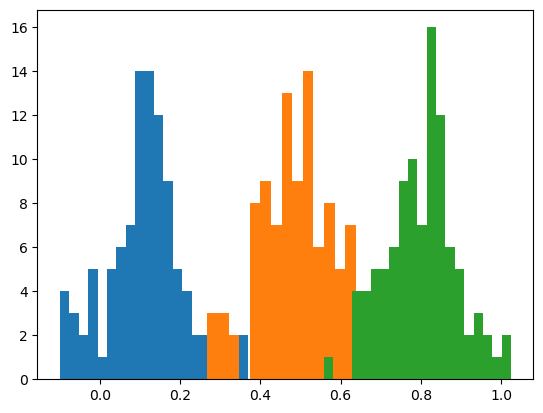

In [9]:
steps = 100
Steps = [[], [], []]
for arm in range(3):    
    for step in range(steps):
        Steps[arm].append(pull_arm(arm))
    plt.hist(Steps[arm], 20)
plt.show()

##2. Epsilon-Greedy


Cet algorithme choisit aléatoirement un bras avec une probabilité  (exploration) et exploite les connaissances actuelles avec une probabilité .

Paramètre principal : , qui contrôle le degré d'exploration.

In [10]:
def epsilon_greedy_algorithm(true_rewards, steps, epsilon=0.1):
    """
    Implements the Epsilon-Greedy algorithm.

    Parameters:
        true_rewards (list): True mean rewards for each arm.
        steps (int): Number of steps (rounds) to simulate.
        epsilon (float): Probability of exploration.

    Returns:
        average_rewards (list): Average rewards at each step.
        optimal_action_percentages (list): Optimal action percentages over time.
    """
    k = len(true_rewards)  # Number of arms
    q_values = np.zeros(k)  # Estimated rewards for each arm
    action_counts = np.zeros(k)  # Number of times each arm is pulled
    rewards = []  # List to store rewards
    optimal_action_count = 0  # Count of optimal actions
    optimal_arm = np.argmax(true_rewards)  # Index of the optimal arm
    optimal_action_percentages = []  # List to store optimal action percentages
    
    # Iterate through each step    
    for step in range(steps):
        # Exploration or exploitation decision
        if np.random.rand() < epsilon:
            action = np.random.choice(k)  # Exploration: choose a random arm
        else:
            action = np.argmax(q_values)  # Exploitation: choose the best arm

        # Pull the chosen arm and get a reward
        reward = pull_arm(action)
        rewards.append(reward)

        # Update action counts and estimated rewards
        action_counts[action] += 1
        q_values[action] += (reward - q_values[action]) / action_counts[action]

        # Track if the optimal action was taken
        if action == optimal_arm:
            optimal_action_count += 1

        # Calculate the optimal action percentage
        optimal_action_percentages.append(optimal_action_count / (step + 1))

    # Calculate the average rewards over time
    average_rewards = np.cumsum(rewards) / (np.arange(1, steps + 1))

    return average_rewards, optimal_action_percentages

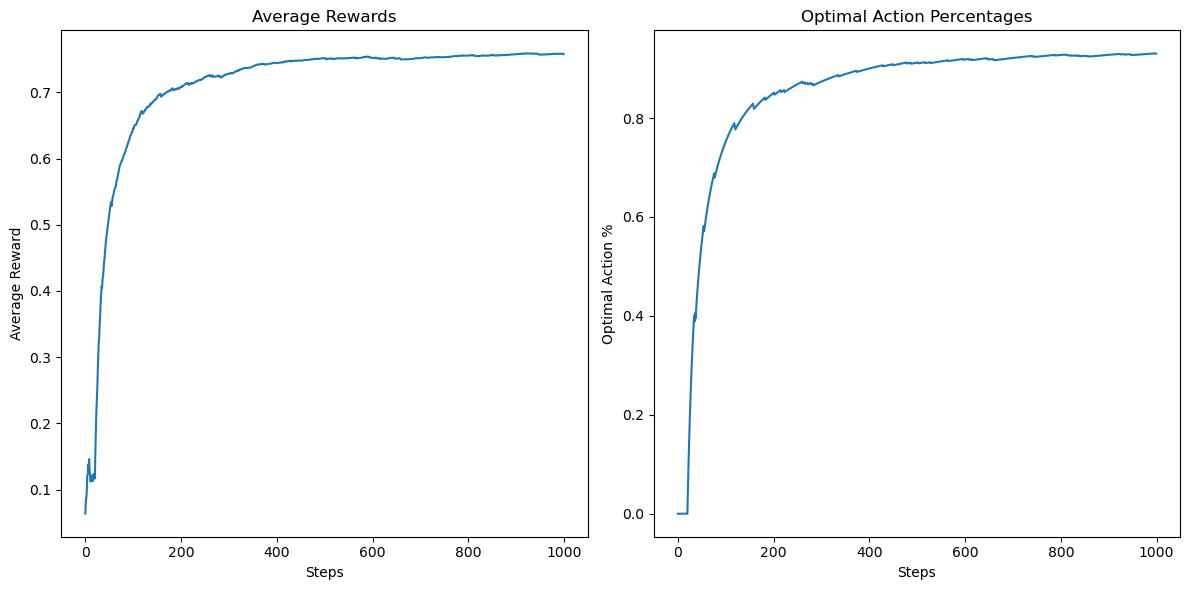

In [12]:
# Example usage
true_rewards = [0.1, 0.5, 0.8]  # True mean rewards for each arm
steps = 1000  # Number of steps
epsilon = 0.1  # Exploration probability

average_rewards, optimal_action_percentages = epsilon_greedy_algorithm(true_rewards, steps, epsilon)
#print(optimal_action_percentages)

# Plotting results
plt.figure(figsize=(12, 6))
# Plot average rewards
plt.subplot(1, 2, 1)
plt.plot(average_rewards)
plt.title("Average Rewards")
plt.xlabel("Steps")
plt.ylabel("Average Reward")

# Plot optimal action percentages
plt.subplot(1, 2, 2)
plt.plot(optimal_action_percentages)
plt.title("Optimal Action Percentages")
plt.xlabel("Steps")
plt.ylabel("Optimal Action %")

plt.tight_layout()
plt.show()

###L'impact de différentes valeurs de epsilon

Pour étudier l'impact de différentes valeurs de epsilon sur les performances de l'algorithme epsilon-greedy, nous allons exécuter l'algorithme pour plusieurs valeurs d'epsilon (0, 0.1, 0.01, 0.2, 0.4, 0.8, 1) et comparer les résultats, notamment les récompenses moyennes et le pourcentage d'actions optimales au fil du temps.

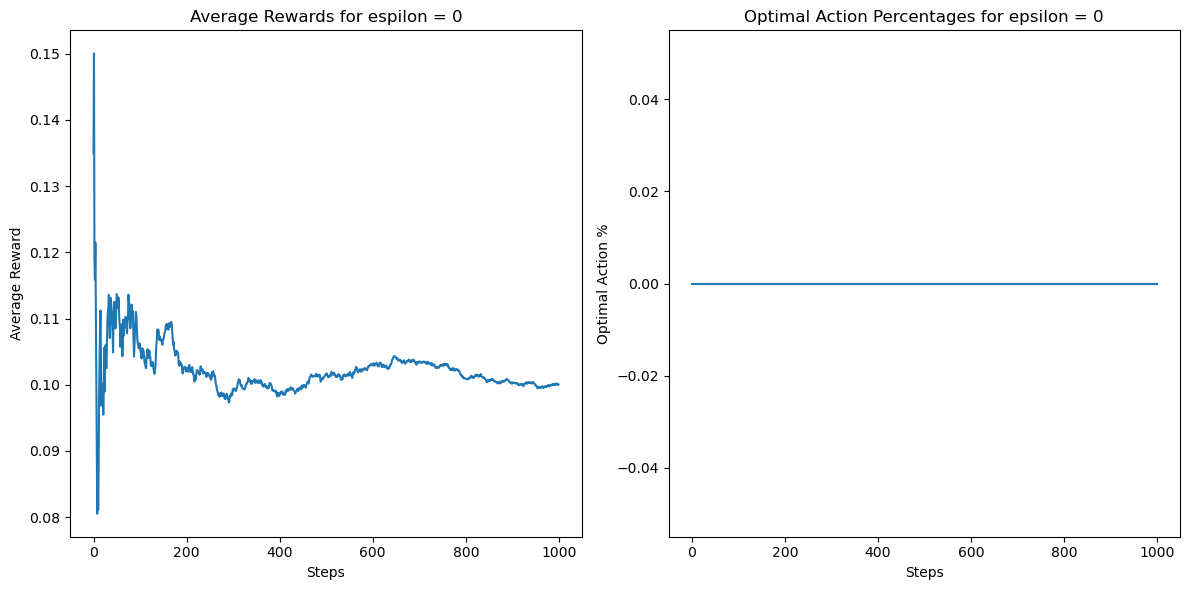

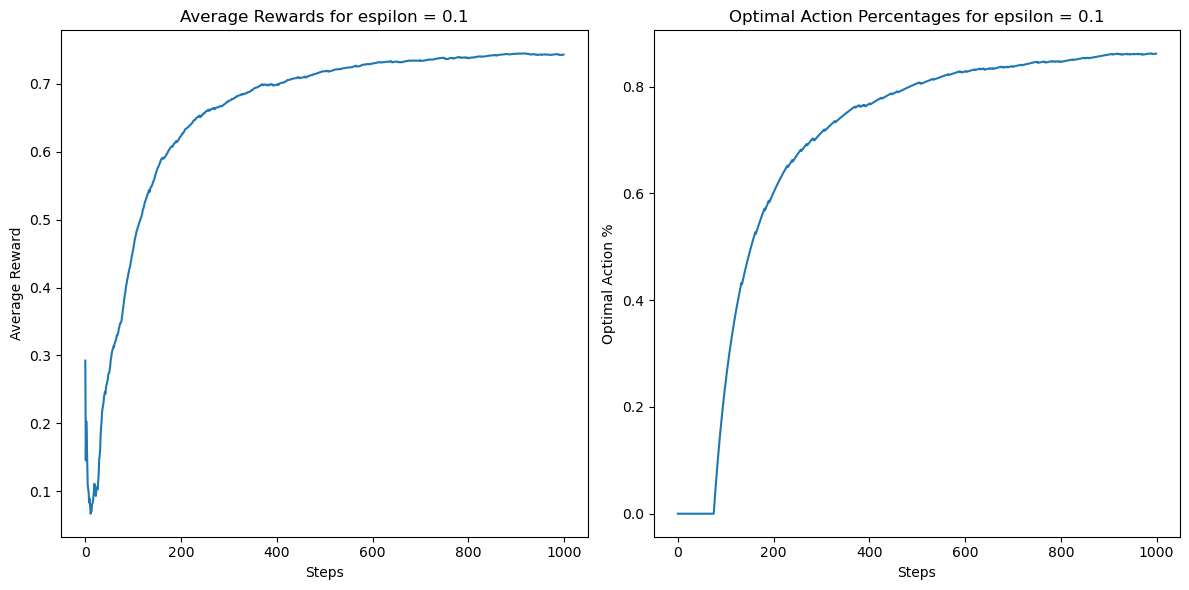

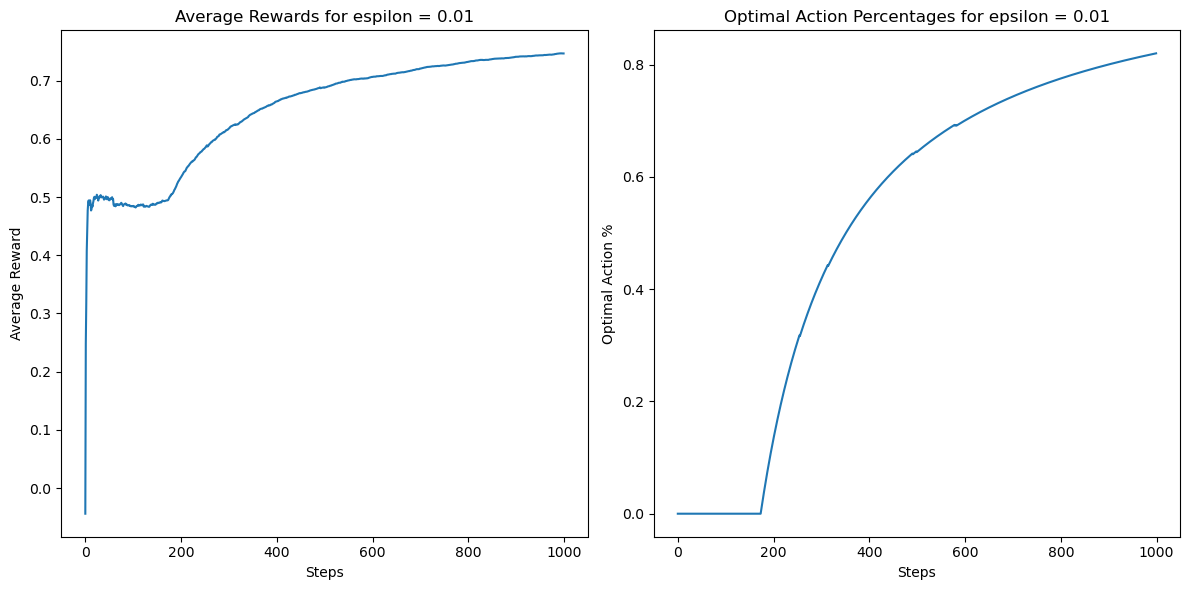

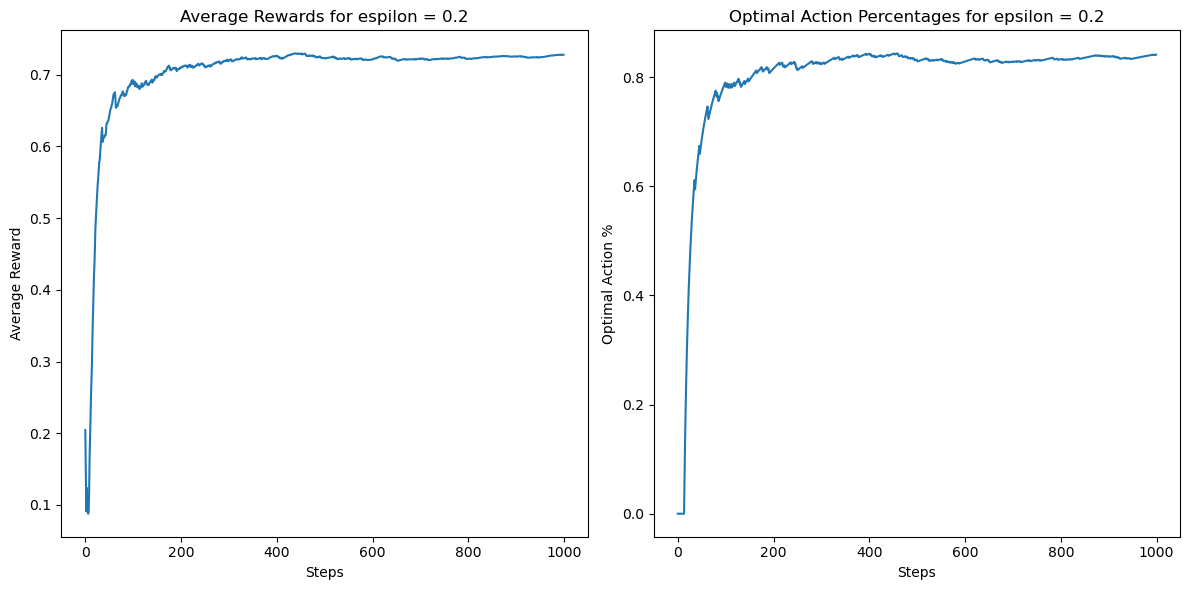

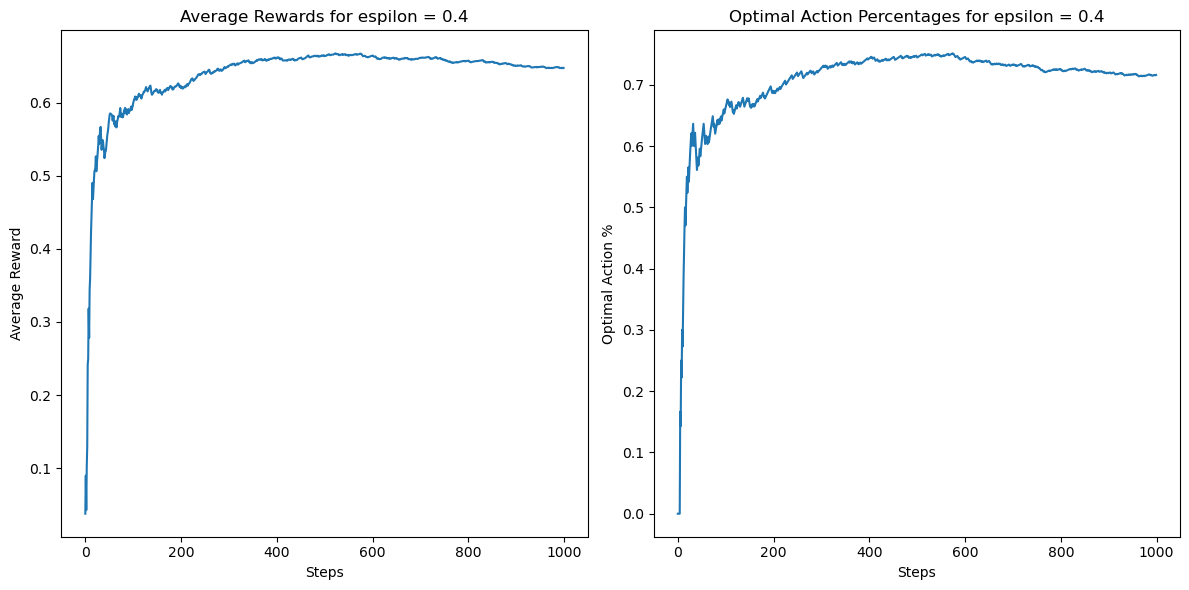

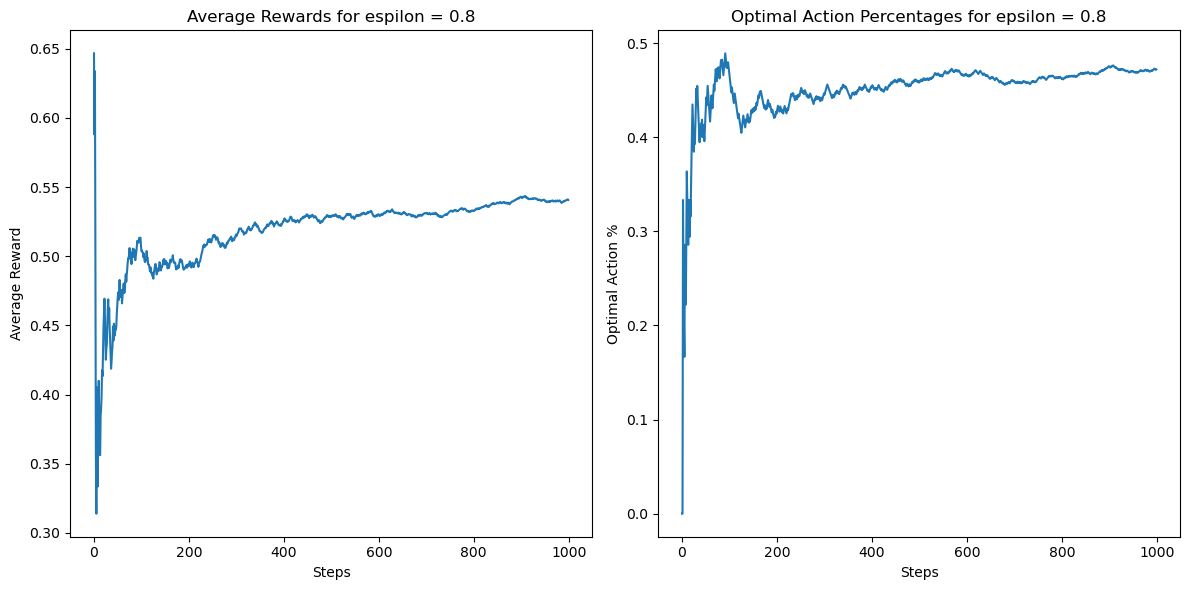

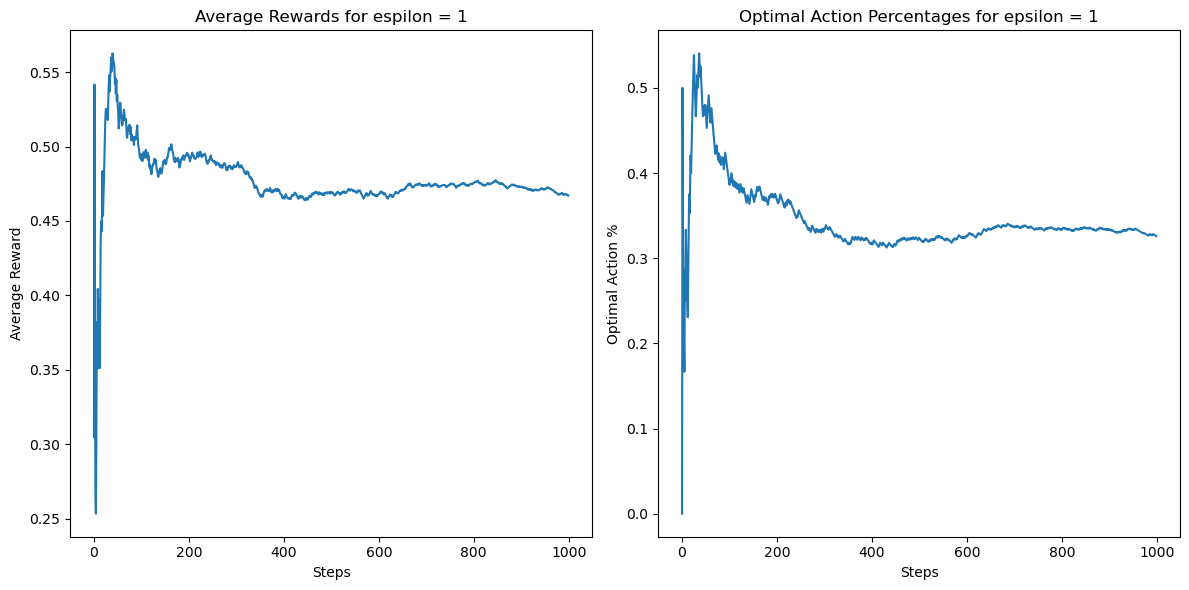

In [13]:
for epsilon in [0, 0.1, 0.01, 0.2, 0.4, 0.8, 1]:
    true_rewards = [0.1, 0.5, 0.8]  # True mean rewards for each arm
    steps = 1000  # Number of steps
    
    average_rewards, optimal_action_percentages = epsilon_greedy_algorithm(true_rewards, steps, epsilon)
    #print(optimal_action_percentages)
    
    # Plotting results
    plt.figure(figsize=(12, 6))
    # Plot average rewards
    plt.subplot(1, 2, 1)
    plt.plot(average_rewards)
    plt.title(f"Average Rewards for espilon = {epsilon}")
    plt.xlabel("Steps")
    plt.ylabel("Average Reward")
    
    # Plot optimal action percentages
    plt.subplot(1, 2, 2)
    plt.plot(optimal_action_percentages)
    plt.title(f"Optimal Action Percentages for epsilon = {epsilon}")
    plt.xlabel("Steps")
    plt.ylabel("Optimal Action %")
    
    plt.tight_layout()
    plt.show()

## 3. Upper Confidence Bound (UCB)


La méthode UCB cherche à équilibrer exploration et exploitation en utilisant un terme de confiance. Ce terme permet de donner une chance aux bras qui ont été moins explorés, même s'ils semblent actuellement moins rentables.

En d'autres termes, l'algorithme ne choisit pas seulement le bras avec la meilleure récompense estimée, mais il prend également en compte l'incertitude associée à cette estimation. Plus un bras est peu exploré, plus son incertitude est élevée, et donc plus il a de chances d'être sélectionné.

## **Formule** :     
Pour chaque bras , l'algorithme calcule un score basé sur la formule suivante :

$UCB_i = Q_i + c \cdot \sqrt{\frac{\ln(t)}{N_i}}
$

1.   $Q_i$: C'est la récompense moyenne estimée pour le bras $i$, calculée à partir des résultats obtenus lors des tirages précédents. Ce terme représente la partie **exploitation** de l'algorithme.
    
2.   $c \cdot \sqrt{\frac{\ln(t)}{N_i}}$: C'est le **terme de confiance**, qui représente l'incertitude sur la récompense estimée du bras $i$. Ce terme est plus grand pour : Les bras qui ont été moins souvent tirés ($N_i$ petit).
 Les premières étapes ($t$ petit), où peu de données sont disponibles.
Ce terme favorise les bras moins explorés, ce qui constitue la partie \textbf{exploration} de l'algorithme.



In [27]:
def ucb_algorithm(true_rewards, steps, c=2):
    """
    Implements the Upper Confidence Bound (UCB) algorithm.

    Parameters:
        true_rewards (list): True mean rewards for each arm.
        steps (int): Number of steps (rounds) to simulate.
        c (float): Exploration parameter.

    Returns:
        average_rewards (list): Average rewards at each step.
        optimal_action_counts (list): Count of optimal actions over time.
    """
    k = len(true_rewards)  # Number of arms
    q_values = np.zeros(k)  # Estimated rewards for each arm
    action_counts = np.zeros(k)  # Number of times each arm is pulled
    rewards = []  # List to store rewards
    optimal_action_count = 0  # Count of optimal actions
    optimal_arm = np.argmax(true_rewards)  # Index of the optimal arm
    optimal_action_percentages = []  # List to store optimal action percentages

    # Iterate through each step
    for step in range(steps):
        # Ensure each arm is pulled at least once
        if step < k:
            action = step
        else:
            # Compute UCB values
            ucb_values = q_values + c * np.sqrt(np.log(step + 1) / (action_counts))
            action = np.argmax(ucb_values)

        # Pull the chosen arm and get a reward
        reward = pull_arm(action)
        rewards.append(reward)

        # Update action counts and estimated rewards
        action_counts[action] += 1
        q_values[action] += (reward - q_values[action]) / action_counts[action]

        # Track if the optimal action was taken
        if action == optimal_arm:
            optimal_action_count += 1

        # Calculate the optimal action percentage
        optimal_action_percentages.append(optimal_action_count / (step + 1))

    # Calculate the average rewards over time
    average_rewards = np.cumsum(rewards) / (np.arange(1, steps + 1))

    return average_rewards, optimal_action_percentages

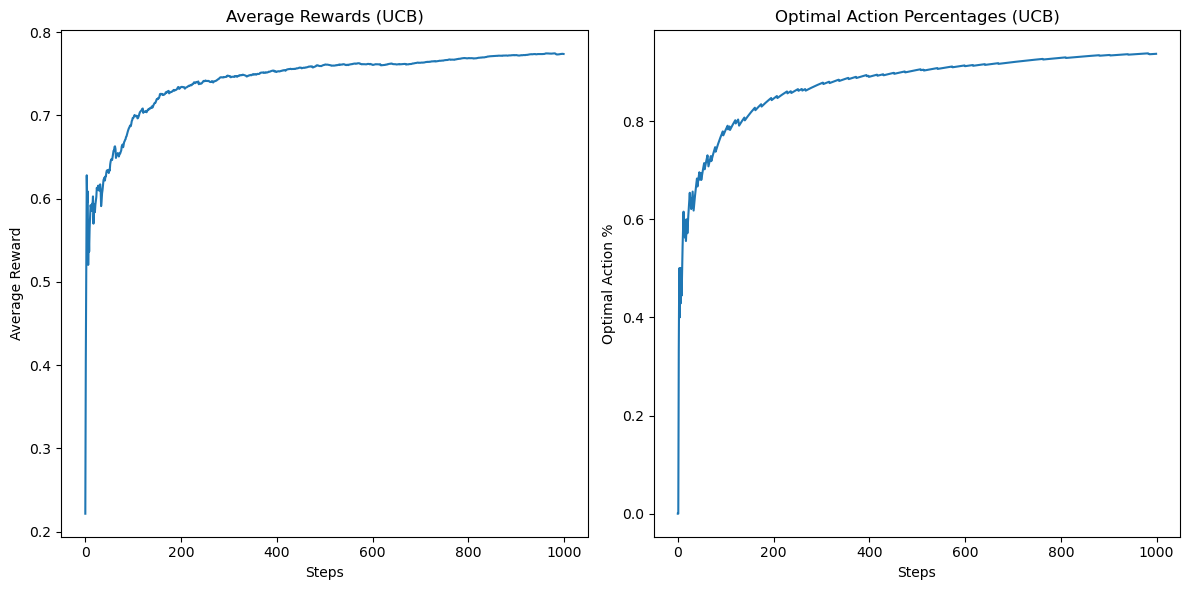

In [28]:
# Example usage
true_rewards = [0.1, 0.5, 0.8]  # True mean rewards for each arm
steps = 1000  # Number of steps
c = 1  # Exploration parameter

average_rewards, optimal_action_percentages = ucb_algorithm(true_rewards, steps, c)
#print(optimal_action_percentages)
# Plotting results

plt.figure(figsize=(12, 6))
# Affichage des récompenses moyennes
plt.subplot(1, 2, 1)
plt.plot(average_rewards)
plt.title("Average Rewards (UCB)")
plt.xlabel("Steps")
plt.ylabel("Average Reward")

# Affichage des pourcentages d'actions optimales
plt.subplot(1, 2, 2)
plt.plot(optimal_action_percentages)
plt.title("Optimal Action Percentages (UCB)")
plt.xlabel("Steps")
plt.ylabel("Optimal Action %")

plt.tight_layout()
plt.show()

## L'impact de la valeur c

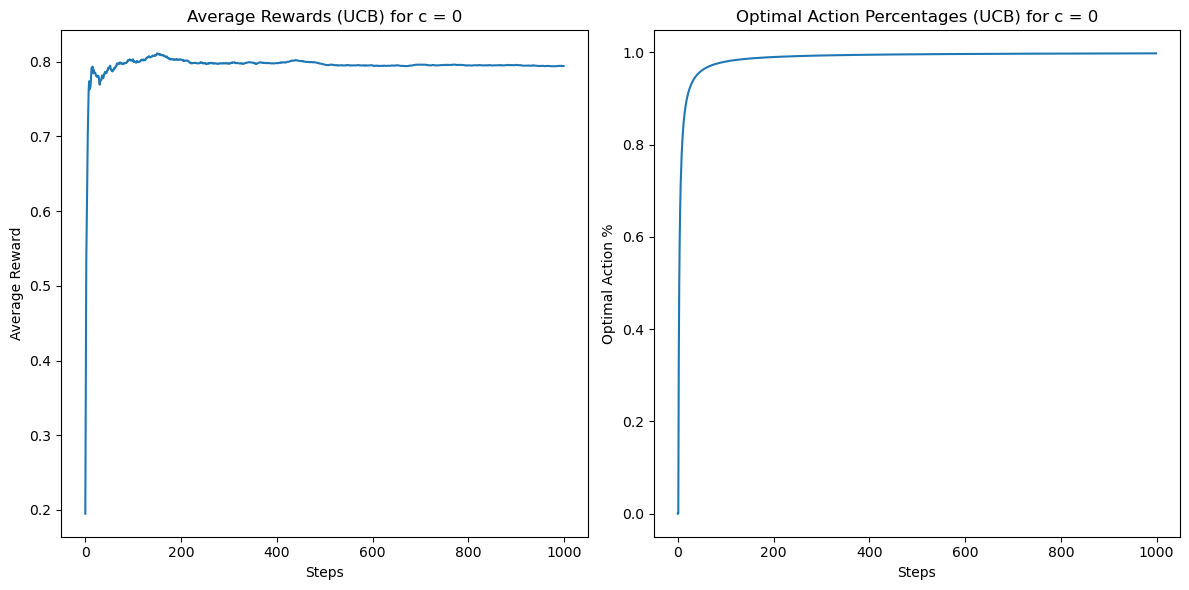

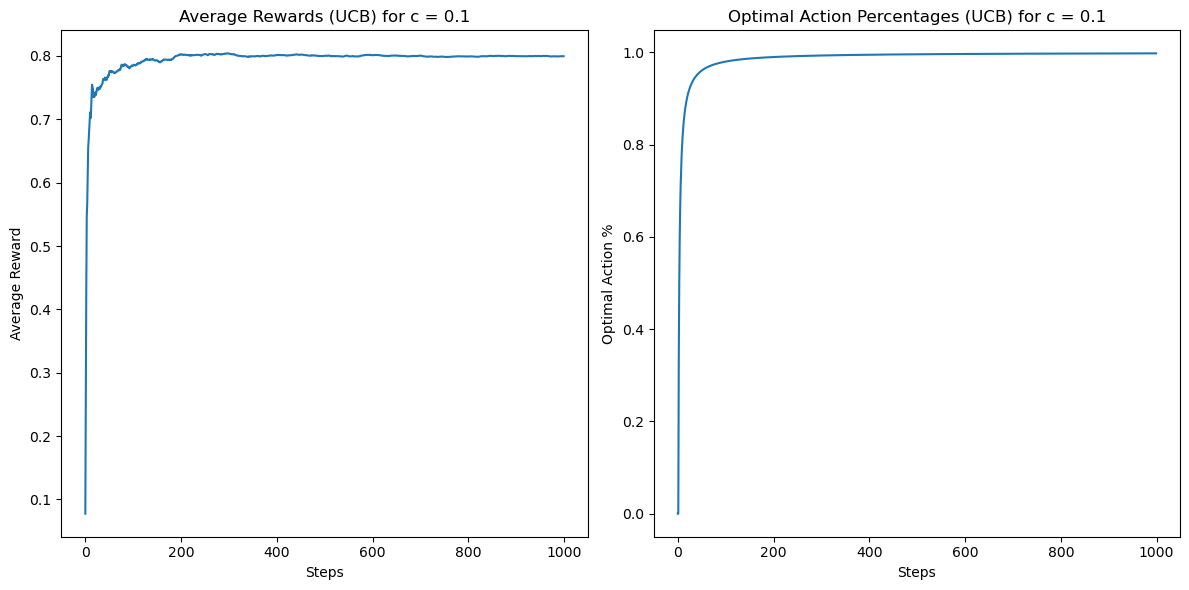

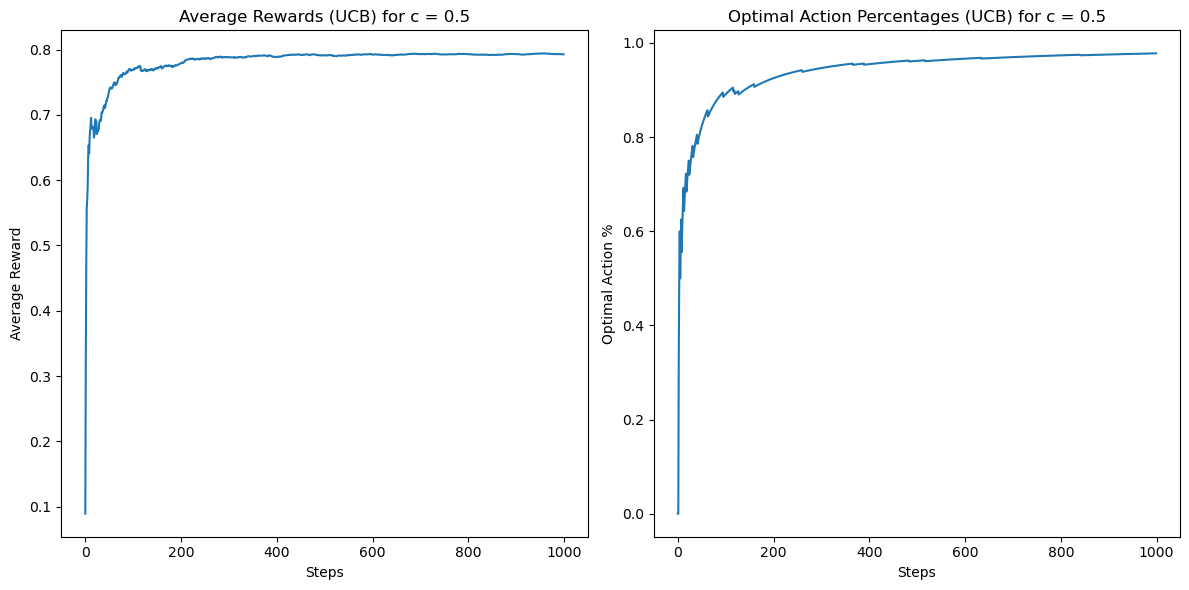

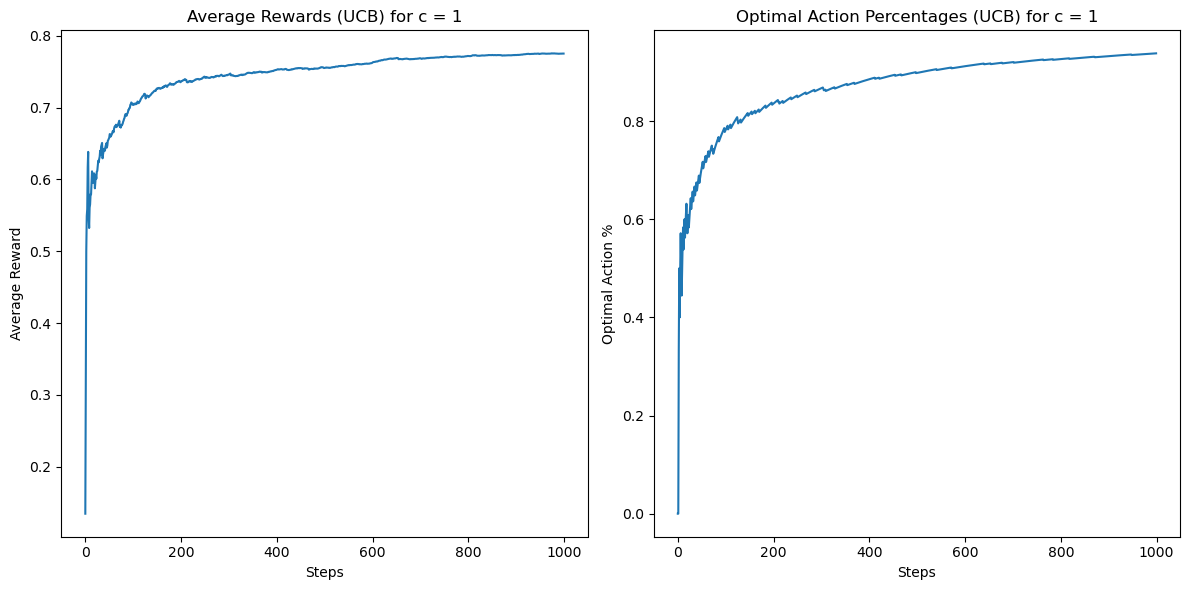

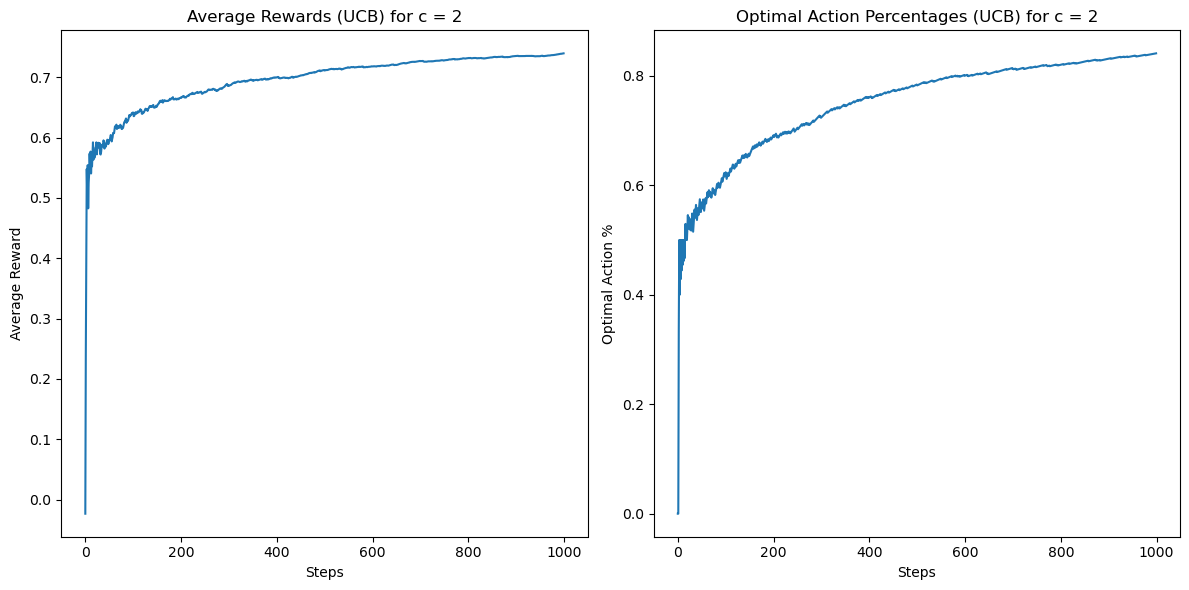

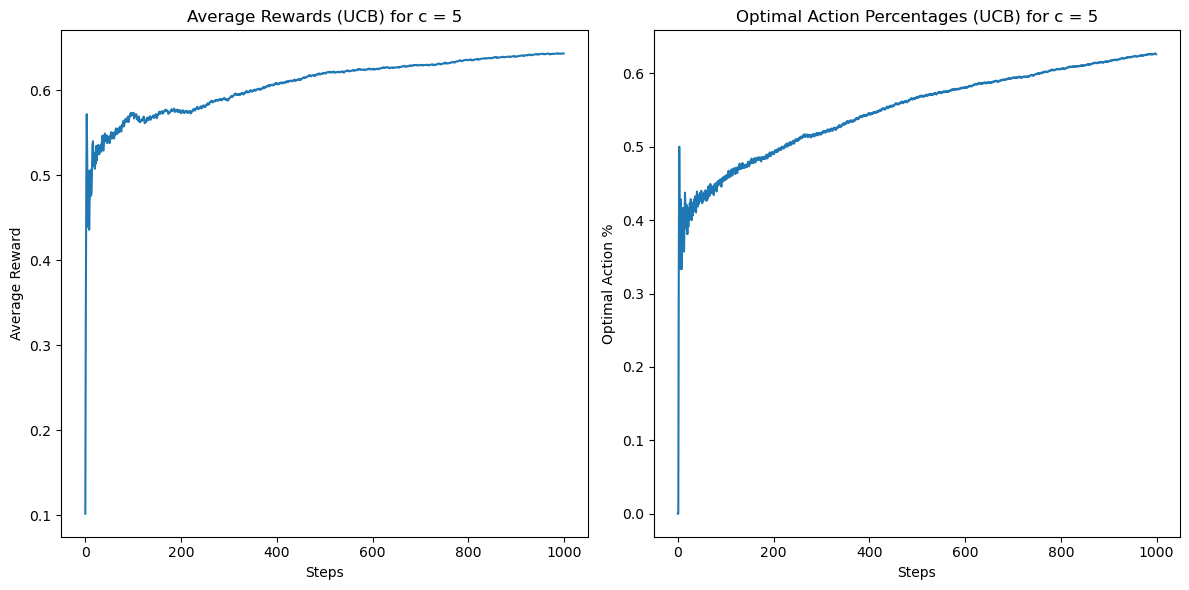

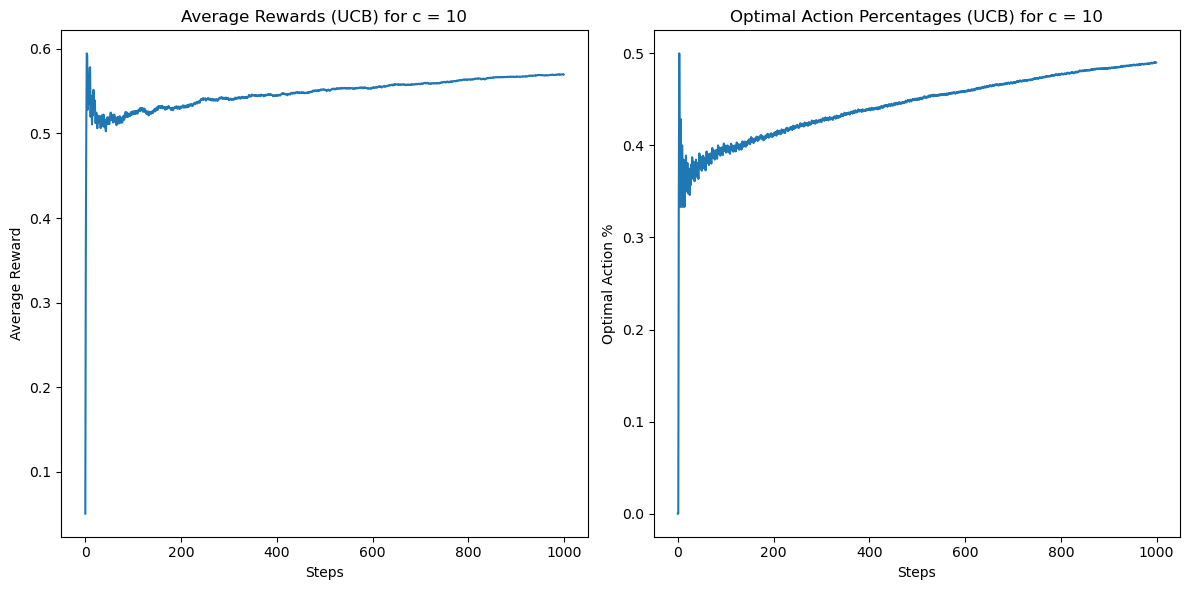

In [29]:
#Study the impact of changing the value of c
for c in [0, 0.1, 0.5, 1, 2, 5, 10]:
    true_rewards = [0.1, 0.5, 0.8]  # True mean rewards for each arm
    steps = 1000  # Number of steps
    
    average_rewards, optimal_action_percentages = ucb_algorithm(true_rewards, steps, c)
    #print(optimal_action_percentages)
    # Plotting results
    
    plt.figure(figsize=(12, 6))
    # Affichage des récompenses moyennes
    plt.subplot(1, 2, 1)
    plt.plot(average_rewards)
    plt.title(f"Average Rewards (UCB) for c = {c}")
    plt.xlabel("Steps")
    plt.ylabel("Average Reward")
    
    # Affichage des pourcentages d'actions optimales
    plt.subplot(1, 2, 2)
    plt.plot(optimal_action_percentages)
    plt.title(f"Optimal Action Percentages (UCB) for c = {c}")
    plt.xlabel("Steps")
    plt.ylabel("Optimal Action %")
    
    plt.tight_layout()
    plt.show()

#5. Comparer les Algorithmes



Simulez les performances des trois algorithmes sur plusieurs exécutions. Tracez les courbes de récompense moyenne et le pourcentage de sélection du bras optimal.

In [ ]:
# Comparer les algorithmes

# Initialiser les résultats


# Moyenne des résultats


# Tracer les résultats

# Conclusion